# Text Classification using 1D CNN (IMDB)

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
# from torch.utils.data import DataLoader
# from torchtext.datasets import IMDB
#from torchtext.data.utils import get_tokenizer
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [42]:
import os
import pandas as pd

csv_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv") and "IMDB" in file:
            csv_path = os.path.join(root, file)

print("Using dataset:", csv_path)

df = pd.read_csv(csv_path)

texts = df['review'].tolist()
labels = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0).tolist()

Using dataset: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [43]:
import re

def tokenize(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      
    text = re.sub(r'[^a-z\s]', '', text)   
    return text.split()

tokenized_texts = [tokenize(t) for t in texts]

In [44]:
from collections import Counter

counter = Counter()

for tokens in tokenized_texts:
    counter.update(tokens)

vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(20000))}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

vocab_size = len(vocab)
print("Vocab size:", vocab_size)

Vocab size: 20002


In [45]:
def encode(tokens):
    return [vocab.get(word, 1) for word in tokens]

In [46]:
import torch

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return torch.tensor(encode(self.texts[idx])), torch.tensor(self.labels[idx])

In [47]:
def collate_fn(batch):
    texts, labels = zip(*batch)

    max_len = 200
    padded = []

    for t in texts:
        if len(t) < max_len:
            t = torch.cat([t, torch.zeros(max_len - len(t))])
        else:
            t = t[:max_len]
        padded.append(t)

    return torch.stack(padded).long(), torch.tensor(labels)

In [48]:
train_texts = tokenized_texts[:40000]
train_labels = labels[:40000]

test_texts = tokenized_texts[40000:]
test_labels = labels[40000:]

In [49]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    IMDBDataset(train_texts, train_labels),
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    IMDBDataset(test_texts, test_labels),
    batch_size=64,
    collate_fn=collate_fn
)

In [50]:
import torch.nn as nn

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.conv1 = nn.Conv1d(embed_dim, 128, 3)
        self.conv2 = nn.Conv1d(embed_dim, 128, 4)
        self.conv3 = nn.Conv1d(embed_dim, 128, 5)

        self.fc = nn.Linear(128 * 3, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x1 = torch.relu(self.conv1(x))
        x2 = torch.relu(self.conv2(x))
        x3 = torch.relu(self.conv3(x))

        x1 = torch.max_pool1d(x1, x1.shape[2]).squeeze(2)
        x2 = torch.max_pool1d(x2, x2.shape[2]).squeeze(2)
        x3 = torch.max_pool1d(x3, x3.shape[2]).squeeze(2)

        x = torch.cat((x1, x2, x3), dim=1)

        return self.fc(self.dropout(x))

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TextCNN(vocab_size, 100, 2).to(device)

import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

train_acc_list = []
val_acc_list = []

def train():
    model.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct / total


def evaluate():
    model.eval()
    correct, total = 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            pred = out.argmax(1)

            preds_all.extend(pred.cpu())
            labels_all.extend(y.cpu())

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total, preds_all, labels_all

In [53]:
for epoch in range(5):
    train_acc = train()
    val_acc, preds, labels = evaluate()

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Train Acc: 0.6666 | Val Acc: 0.7864
Epoch 2 | Train Acc: 0.7800 | Val Acc: 0.8346
Epoch 3 | Train Acc: 0.8296 | Val Acc: 0.8529
Epoch 4 | Train Acc: 0.8634 | Val Acc: 0.8665
Epoch 5 | Train Acc: 0.8896 | Val Acc: 0.8695


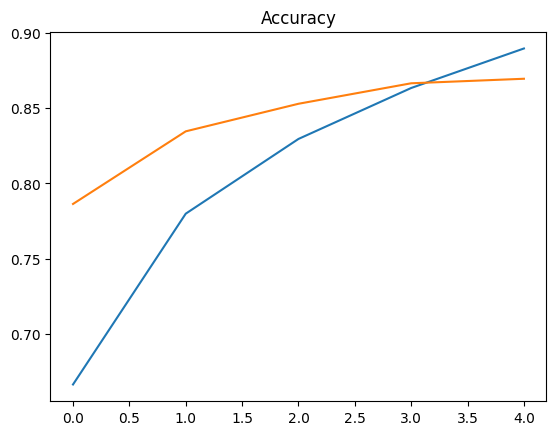

In [54]:
plt.figure()
plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.title("Accuracy")
plt.show()

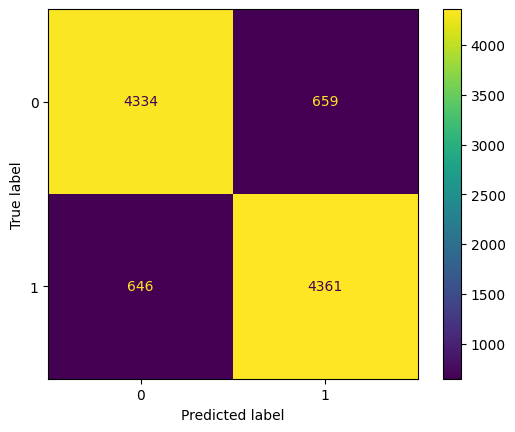

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()